# Step 4: Baseline Model

Establishes a benchmark RMSLE score before moving to the challenger model.

Three baselines compared:
| Baseline | Description |
|----------|-------------|
| **Mean** | Predict the historical mean sales per `(store_nbr, family)` |
| **Lag-364** | Predict same day from exactly 52 weeks ago (seasonal naive) |
| **Lag-7** | Predict same day from last week |

Evaluation metric: **RMSLE** (Root Mean Squared Log Error) — same as the Kaggle competition.

$$\text{RMSLE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}\left(\log(1+\hat{y}_i) - \log(1+y_i)\right)^2}$$

Validation split: last 28 days of training data (2017-07-19 → 2017-08-15), matching the test period length.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120

DATA_DIR = 'data/'

# Validation window: last 28 days of training
VAL_START = pd.Timestamp('2017-07-19')
VAL_END   = pd.Timestamp('2017-08-15')
TR_END    = pd.Timestamp('2017-07-18')

## 1. Load Data

In [2]:
# Load from feature parquet; fall back to raw CSV if Step 3 hasn't been run yet
try:
    feat_train = pd.read_parquet(DATA_DIR + 'features_train.parquet')
    feat_test  = pd.read_parquet(DATA_DIR + 'features_test.parquet')
    # Baseline only needs these columns
    train_full = feat_train[['date', 'store_nbr', 'family_enc', 'sales']].copy()
    test_full  = feat_test[['id', 'date', 'store_nbr', 'family_enc']].copy()
    FAMILY_COL = 'family_enc'
    print('Loaded from features_train.parquet')
except Exception:
    train_full = pd.read_csv(DATA_DIR + 'train.csv', parse_dates=['date'])
    test_full  = pd.read_csv(DATA_DIR + 'test.csv',  parse_dates=['date'])
    FAMILY_COL = 'family'
    print('Loaded from raw CSV (Step 3 parquet not found)')

print(f'train: {train_full.shape}  |  test: {test_full.shape}')

Loaded from features_train.parquet
train: (3000888, 4)  |  test: (28512, 4)


## 2. Train / Validation Split

In [3]:
tr  = train_full[train_full['date'] <= TR_END].copy()
val = train_full[(train_full['date'] >= VAL_START) & (train_full['date'] <= VAL_END)].copy()

print(f'Train split : {tr["date"].min().date()} -> {tr["date"].max().date()}  ({tr["date"].nunique()} days, {len(tr):,} rows)')
print(f'Val split   : {val["date"].min().date()} -> {val["date"].max().date()}  ({val["date"].nunique()} days, {len(val):,} rows)')

Train split : 2013-01-01 -> 2017-07-18  (1656 days, 2,950,992 rows)
Val split   : 2017-07-19 -> 2017-08-15  (28 days, 49,896 rows)


## 3. RMSLE Helper

In [4]:
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)   # predictions must be >= 0
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

# Store results for comparison
results = {}

## 4. Baseline 1 — Mean per (store, family)

In [5]:
mean_lookup = (
    tr.groupby(['store_nbr', FAMILY_COL])['sales']
    .mean()
    .reset_index()
    .rename(columns={'sales': 'pred'})
)

val_mean = val.merge(mean_lookup, on=['store_nbr', FAMILY_COL], how='left')
val_mean['pred'] = val_mean['pred'].fillna(0)

score_mean = rmsle(val_mean['sales'], val_mean['pred'])
results['Mean (store+family)'] = score_mean
print(f'Baseline 1 — Mean per (store, family)   RMSLE: {score_mean:.4f}')

Baseline 1 — Mean per (store, family)   RMSLE: 0.6900


## 5. Baseline 2 — Seasonal Naive (lag-364)

In [6]:
# For each val row, look up sales from exactly 52 weeks (364 days) earlier
lag364_lookup = (
    tr[['date', 'store_nbr', FAMILY_COL, 'sales']]
    .copy()
    .rename(columns={'sales': 'pred'})
)
lag364_lookup['date'] = lag364_lookup['date'] + pd.Timedelta(days=364)

val_lag364 = val.merge(lag364_lookup, on=['date', 'store_nbr', FAMILY_COL], how='left')
val_lag364['pred'] = val_lag364['pred'].fillna(0)

score_lag364 = rmsle(val_lag364['sales'], val_lag364['pred'])
results['Seasonal Naive (lag-364)'] = score_lag364
print(f'Baseline 2 — Seasonal Naive (lag-364)   RMSLE: {score_lag364:.4f}')

Baseline 2 — Seasonal Naive (lag-364)   RMSLE: 0.9430


## 6. Baseline 3 — Last Week (lag-7)

In [7]:
lag7_lookup = (
    tr[['date', 'store_nbr', FAMILY_COL, 'sales']]
    .copy()
    .rename(columns={'sales': 'pred'})
)
lag7_lookup['date'] = lag7_lookup['date'] + pd.Timedelta(days=7)

val_lag7 = val.merge(lag7_lookup, on=['date', 'store_nbr', FAMILY_COL], how='left')
val_lag7['pred'] = val_lag7['pred'].fillna(0)

score_lag7 = rmsle(val_lag7['sales'], val_lag7['pred'])
results['Last Week (lag-7)'] = score_lag7
print(f'Baseline 3 — Last Week (lag-7)          RMSLE: {score_lag7:.4f}')

Baseline 3 — Last Week (lag-7)          RMSLE: 3.8378


## 7. Comparison Table & Chart

In [8]:
results_df = (
    pd.DataFrame.from_dict(results, orient='index', columns=['RMSLE'])
    .sort_values('RMSLE')
)
print('=== Baseline Comparison ===')
print(results_df.to_string())
print(f'\nBest baseline: {results_df.index[0]}  (RMSLE = {results_df.iloc[0,0]:.4f})')

=== Baseline Comparison ===
                             RMSLE
Mean (store+family)       0.689953
Seasonal Naive (lag-364)  0.943016
Last Week (lag-7)         3.837799

Best baseline: Mean (store+family)  (RMSLE = 0.6900)


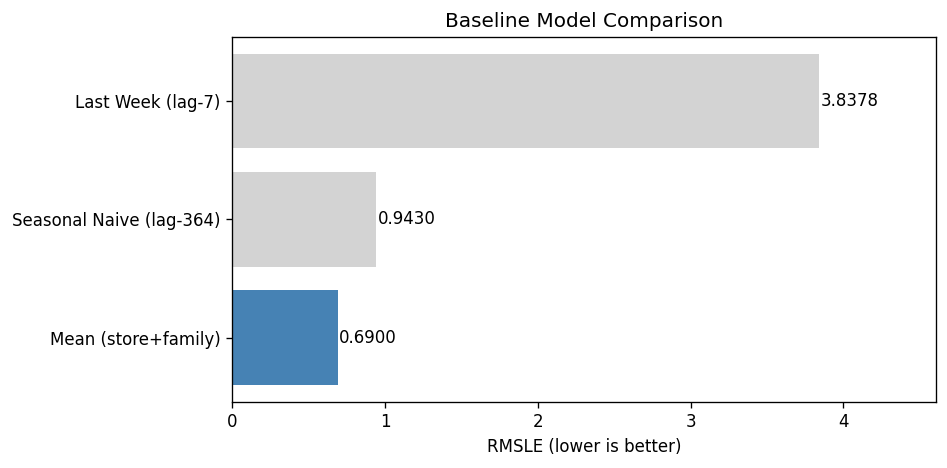

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if i == 0 else 'lightgray' for i in range(len(results_df))]
bars = ax.barh(results_df.index, results_df['RMSLE'], color=colors, edgecolor='none')
for bar, val_score in zip(bars, results_df['RMSLE']):
    ax.text(val_score + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val_score:.4f}', va='center', fontsize=10)
ax.set_xlabel('RMSLE (lower is better)')
ax.set_title('Baseline Model Comparison')
ax.set_xlim(0, results_df['RMSLE'].max() * 1.2)
plt.tight_layout()
plt.show()

## 8. Error Analysis — Best Baseline

In [10]:
# Analyze where the mean baseline makes the largest errors
val_mean['sq_log_err'] = (np.log1p(val_mean['pred']) - np.log1p(val_mean['sales'])) ** 2

# RMSLE by family
if FAMILY_COL == 'family':
    family_err = val_mean.groupby('family')['sq_log_err'].mean().apply(np.sqrt).sort_values(ascending=False)
    print('RMSLE by family (top 10 worst):')
    print(family_err.head(10).round(4))
else:
    family_err = val_mean.groupby('family_enc')['sq_log_err'].mean().apply(np.sqrt).sort_values(ascending=False)
    print('RMSLE by family_enc (top 10 worst):')
    print(family_err.head(10).round(4))

RMSLE by family_enc (top 10 worst):
family_enc
31    1.3995
22    0.9076
20    0.8646
21    0.8499
13    0.8249
26    0.7658
16    0.7622
23    0.7593
30    0.7297
6     0.7269
Name: sq_log_err, dtype: float64


In [11]:
# RMSLE by store
store_err = val_mean.groupby('store_nbr')['sq_log_err'].mean().apply(np.sqrt).sort_values(ascending=False)
print('RMSLE by store (top 10 worst):')
print(store_err.head(10).round(4))

RMSLE by store (top 10 worst):
store_nbr
52    2.4242
22    0.9162
21    0.8679
20    0.8073
42    0.7847
45    0.7734
29    0.7400
50    0.7350
46    0.7323
47    0.7312
Name: sq_log_err, dtype: float64


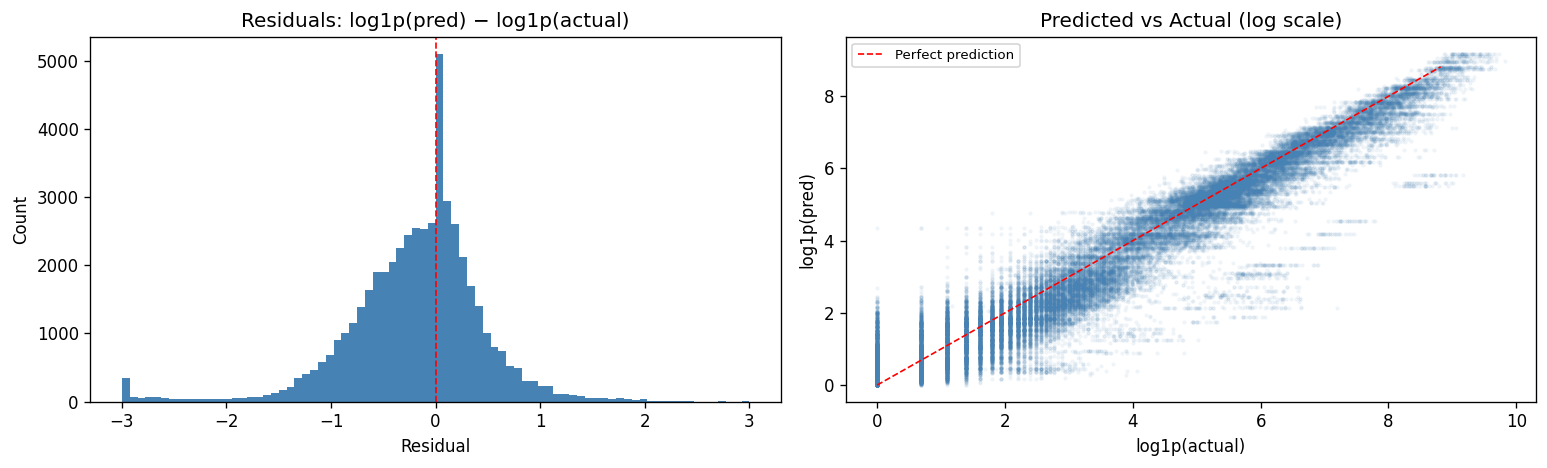

In [12]:
# Residual distribution
residuals = np.log1p(val_mean['pred']) - np.log1p(val_mean['sales'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(residuals.clip(-3, 3), bins=80, color='steelblue', edgecolor='none')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Residuals: log1p(pred) − log1p(actual)')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Count')

axes[1].scatter(np.log1p(val_mean['sales']), np.log1p(val_mean['pred']),
                alpha=0.05, s=3, color='steelblue')
max_val = np.log1p(val_mean['sales']).quantile(0.99)
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect prediction')
axes[1].set_title('Predicted vs Actual (log scale)')
axes[1].set_xlabel('log1p(actual)')
axes[1].set_ylabel('log1p(pred)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 9. Generate Test Predictions (Best Baseline)

In [13]:
# Retrain mean lookup on the FULL training data (not just tr split)
full_mean_lookup = (
    train_full.groupby(['store_nbr', FAMILY_COL])['sales']
    .mean()
    .reset_index()
    .rename(columns={'sales': 'pred'})
)

test_pred = test_full.merge(full_mean_lookup, on=['store_nbr', FAMILY_COL], how='left')
test_pred['pred'] = test_pred['pred'].fillna(0).clip(lower=0)

submission = test_pred[['id', 'pred']].rename(columns={'pred': 'sales'})
submission.to_csv(DATA_DIR + 'submission_baseline.csv', index=False)

print(f'Test predictions saved to data/submission_baseline.csv')
print(f'Rows: {len(submission):,}')
print(f'Pred stats:')
print(submission['sales'].describe().round(2))

Test predictions saved to data/submission_baseline.csv
Rows: 28,512
Pred stats:
count    28512.00
mean       357.78
std        961.60
min          0.00
25%          2.88
50%         19.81
75%        221.09
max       9730.44
Name: sales, dtype: float64


## 10. Summary

In [14]:
print('============ Baseline Summary ============')
print(f'Validation period : {VAL_START.date()} -> {VAL_END.date()} (28 days)')
print(f'Metric            : RMSLE')
print()
for name, score in sorted(results.items(), key=lambda x: x[1]):
    marker = ' <- best baseline' if score == min(results.values()) else ''
    print(f'  {name:30s}: {score:.4f}{marker}')
print()
print(f'Target for Step 5 : RMSLE < {min(results.values()):.4f} (beat the mean baseline)')
print('==========================================')

============ Baseline Summary ============
Validation period : 2017-07-19 -> 2017-08-15 (28 days)
Metric            : RMSLE

  Mean (store+family)           : 0.6900 <- best baseline
  Seasonal Naive (lag-364)      : 0.9430
  Last Week (lag-7)             : 3.8378

Target for Step 5 : RMSLE < 0.6900 (beat the mean baseline)
